# Урок 3. Компьютерное зрение: transfer learning и CLIP

🎯 **Цели урока**

- использовать предобученную ResNet-18 как экстрактор признаков (linear probe);
- дообучить её целиком (fine-tuning) и сравнить;
- классифицировать снимки без единого размеченного примера через CLIP (zero-shot);
- увидеть, как формулировка текстового запроса меняет качество zero-shot — первый шаг к промптам;
- понять, сколько размеченных данных стоит «знание» предобученной модели.

📖 **Теория:** раздел «Компьютерное зрение одной главой».

**Данные:** EuroSAT (лицензия MIT) — 27 тысяч спутниковых снимков Sentinel-2 размером 64×64 в 10 классах.
**Модели:** ResNet-18 из timm (веса Apache 2.0) и CLIP ViT-B/32 от OpenAI (MIT).

⏱ Первый запуск скачивает ~700 МБ. Урок тяжёлый, поэтому в CI не выполняется; выводы в ноутбуке
записаны на Mac M1 (MPS).

In [1]:
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")  # tqdm в Jupyter без ipywidgets
warnings.filterwarnings("ignore", category=FutureWarning)

import time  # noqa: E402

import matplotlib.pyplot as plt
import numpy as np
import timm  # noqa: E402
import torch
from huggingface_hub.utils import logging as hub_logging
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from transformers import CLIPModel, CLIPProcessor
from transformers.utils import logging as hf_logging

from mlcourse import data_dir, get_device, seed_everything

hf_logging.set_verbosity_error()
hub_logging.set_verbosity_error()  # без напоминаний про HF_TOKEN: публичные модели качаются и так
seed_everything(0)
device = get_device()
print("устройство:", device)

устройство: mps


## 1. Данные

27000 снимков, 10 классов: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


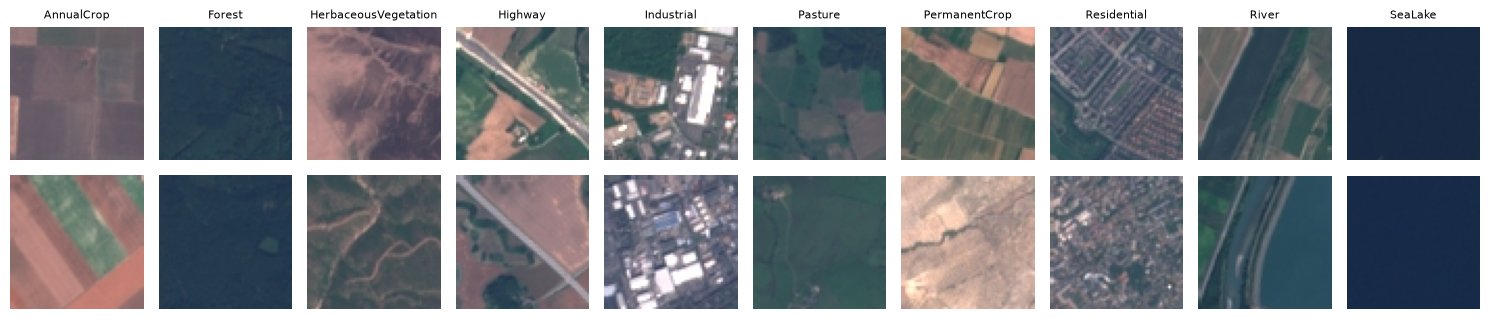

In [2]:
eurosat = datasets.EuroSAT(data_dir("eurosat"), download=True)
classes = eurosat.classes
targets = np.array(eurosat.targets)
print(len(eurosat), "снимков,", len(classes), "классов:", classes)

fig, axes = plt.subplots(2, 10, figsize=(15, 3.4))
for c in range(10):
    for row in range(2):
        idx = np.flatnonzero(targets == c)[row * 7]
        axes[row, c].imshow(eurosat[idx][0])
        axes[row, c].axis("off")
    axes[0, c].set_title(classes[c], fontsize=8)
plt.tight_layout()
plt.show()

Отложим тест — по 200 снимков каждого класса. Для обучения возьмём до 300 снимков на класс:
этого хватит, чтобы увидеть все эффекты, и урок останется быстрым.

In [3]:
rng = np.random.default_rng(0)
test_idx, train_idx = [], []
for c in range(10):
    idx = rng.permutation(np.flatnonzero(targets == c))
    test_idx += idx[:200].tolist()
    train_idx += idx[200:500].tolist()
test_idx, train_idx = np.array(test_idx), np.array(train_idx)
y_test, y_train = targets[test_idx], targets[train_idx]
print("train:", len(train_idx), " test:", len(test_idx))

train: 3000  test: 2000


## 2. ResNet-18 как экстрактор признаков

`num_classes=0` отрезает последний слой-классификатор ImageNet: на выходе — вектор из 512 признаков.
timm знает, как готовить картинки для этой модели: размер 224, нормализация как при обучении.

In [4]:
resnet = timm.create_model("resnet18.a1_in1k", pretrained=True, num_classes=0).to(device).eval()
cfg = timm.data.resolve_data_config({}, model=resnet)
eval_tf = timm.data.create_transform(**cfg)
print(cfg)


class Transformed(torch.utils.data.Dataset):
    """EuroSAT с преобразованием картинок под модель."""

    def __init__(self, indices, transform):
        self.indices, self.transform = indices, transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, label = eurosat[int(self.indices[i])]
        return self.transform(img), label


@torch.no_grad()
def resnet_features(indices):
    loader = DataLoader(Transformed(indices, eval_tf), batch_size=128)
    return torch.cat([resnet(x.to(device)).cpu() for x, _ in loader]).numpy()


start = time.perf_counter()
F_train, F_test = resnet_features(train_idx), resnet_features(test_idx)
print(F_train.shape, f"{time.perf_counter() - start:.0f} с")

{'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 0.95, 'crop_mode': 'center'}


(3000, 512) 25 с


## 3. CLIP: признаки картинок и zero-shot

CLIP кодирует и картинки, и тексты в одно 512-мерное пространство.

In [5]:
clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device).eval()
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")


def normalize(v):
    return v / v.norm(dim=-1, keepdim=True)


@torch.no_grad()
def clip_image_features(indices):
    feats = []
    for s in range(0, len(indices), 256):
        images = [eurosat[int(i)][0] for i in indices[s : s + 256]]
        inputs = processor(images=images, return_tensors="pt").to(device)
        feats.append(normalize(clip.get_image_features(**inputs).pooler_output).cpu())
    return torch.cat(feats)


@torch.no_grad()
def clip_text_features(texts):
    inputs = processor(text=texts, return_tensors="pt", padding=True).to(device)
    return normalize(clip.get_text_features(**inputs).pooler_output).cpu()


start = time.perf_counter()
C_train, C_test = clip_image_features(train_idx), clip_image_features(test_idx)
print(C_train.shape, f"{time.perf_counter() - start:.0f} с")

torch.Size([3000, 512]) 56 с


Zero-shot: для каждого класса пишем текст, считаем его эмбеддинг и относим снимок к классу с самым
похожим текстом. Сравним три варианта «промпта».

In [6]:
readable = {
    "AnnualCrop": "annual crop land", "Forest": "forest", "HerbaceousVegetation": "brushland or shrubland",
    "Highway": "highway or road", "Industrial": "industrial buildings", "Pasture": "pasture land",
    "PermanentCrop": "permanent crop land", "Residential": "residential buildings", "River": "river",
    "SeaLake": "sea or lake",
}
templates = [
    "a centered satellite photo of {}.", "a satellite photo of {}.", "an aerial photo of {}.",
    "a satellite image showing {}.", "{} seen from space.",
]


def zero_shot(text_features):
    pred = (C_test @ text_features.T).argmax(dim=1).numpy()
    return pred, (pred == y_test).mean()


variants = {
    "имя класса как есть": clip_text_features(classes),
    "понятное название": clip_text_features([readable[c] for c in classes]),
    "«a centered satellite photo of …»": clip_text_features([templates[0].format(readable[c]) for c in classes]),
    "ансамбль из 5 шаблонов": normalize(torch.stack([
        clip_text_features([t.format(readable[c]) for t in templates]).mean(dim=0) for c in classes
    ])),
}
zs_results = {name: zero_shot(tf) for name, tf in variants.items()}
for name, (_, acc) in zs_results.items():
    print(f"{name:36} accuracy {acc:.3f}")

имя класса как есть                  accuracy 0.343
понятное название                    accuracy 0.453
«a centered satellite photo of …»    accuracy 0.468
ансамбль из 5 шаблонов               accuracy 0.489


Модель та же, данные те же — меняется только текст. Понятные названия вместо `HerbaceousVegetation`,
упоминание спутниковой съёмки и усреднение по нескольким формулировкам поднимают точность
на полтора десятка процентных пунктов. Это и есть prompt engineering, только для модели эмбеддингов. В M09 займёмся им
для LLM систематически.

Где ошибается лучший вариант?

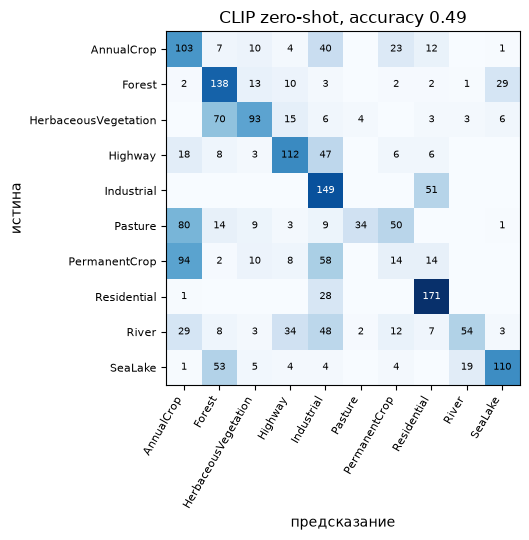

In [7]:
zs_pred, zs_acc = zs_results["ансамбль из 5 шаблонов"]
cm = confusion_matrix(y_test, zs_pred)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10), classes, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(10), classes, fontsize=8)
for (i, j), v in np.ndenumerate(cm):
    if v:
        ax.text(j, i, v, ha="center", va="center", fontsize=7, color="w" if v > 120 else "k")
ax.set(xlabel="предсказание", ylabel="истина", title=f"CLIP zero-shot, accuracy {zs_acc:.2f}")
plt.tight_layout()
plt.show()

Города CLIP узнаёт уверенно: жилые и промышленные кварталы похожи на то, что он видел в интернете.
Пастбища и многолетние насаждения он почти всегда принимает за пашню: сверху это зелёные и бурые
прямоугольники, а словесное описание мало помогает их различить.

## 4. Linear probe: сколько размеченных примеров нужно

Обучим логистическую регрессию поверх замороженных признаков ResNet и CLIP, давая ей от 1 до 300
примеров на класс. Для малых размеров усредним по нескольким случайным выборкам.

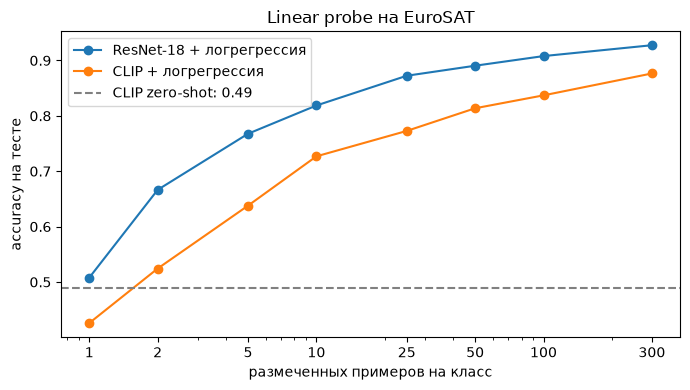

ResNet-18 + логрегрессия {1: 0.508, 2: 0.666, 5: 0.768, 10: 0.819, 25: 0.872, 50: 0.89, 100: 0.908, 300: 0.927}
CLIP + логрегрессия {1: 0.426, 2: 0.524, 5: 0.638, 10: 0.727, 25: 0.773, 50: 0.814, 100: 0.837, 300: 0.876}


In [8]:
def probe_accuracy(F_tr, F_te, n_per_class, seeds=5):
    accs = []
    for seed in range(seeds if n_per_class < 300 else 1):
        r = np.random.default_rng(seed)
        idx = np.concatenate([r.choice(np.flatnonzero(y_train == c), n_per_class, replace=False) for c in range(10)])
        clf = LogisticRegression(max_iter=3000, C=1.0).fit(F_tr[idx], y_train[idx])
        accs.append(clf.score(F_te, y_test))
    return float(np.mean(accs))


shots = [1, 2, 5, 10, 25, 50, 100, 300]
curves = {
    "ResNet-18 + логрегрессия": [probe_accuracy(F_train, F_test, n) for n in shots],
    "CLIP + логрегрессия": [probe_accuracy(C_train.numpy(), C_test.numpy(), n) for n in shots],
}

fig, ax = plt.subplots(figsize=(7, 4))
for name, accs in curves.items():
    ax.semilogx(shots, accs, marker="o", label=name)
ax.axhline(zs_acc, color="gray", ls="--", label=f"CLIP zero-shot: {zs_acc:.2f}")
ax.set(xlabel="размеченных примеров на класс", ylabel="accuracy на тесте", title="Linear probe на EuroSAT")
ax.set_xticks(shots, [str(s) for s in shots])
ax.legend()
plt.tight_layout()
plt.show()
for name, accs in curves.items():
    print(name, {n: round(a, 3) for n, a in zip(shots, accs)})

## 5. Fine-tuning: дообучить всю сеть

Теперь не замораживаем ResNet. Последний слой новый, со случайными весами, — ему нужен шаг побольше
(10⁻³). Предобученному телу — маленький (10⁻⁴), чтобы не разрушить готовые признаки. Оба шага
затухают по косинусу (M01). Добавим простую аугментацию — отражения и повороты на 90°:
у спутникового снимка нет «верха».

In [9]:
def augment(x):
    if torch.rand(1) < 0.5:
        x = x.flip(-1)
    return torch.rot90(x, int(torch.randint(0, 4, (1,))), dims=(-2, -1))


class Augmented(Transformed):
    def __getitem__(self, i):
        x, label = super().__getitem__(i)
        return augment(x), label


seed_everything(0)
model = timm.create_model("resnet18.a1_in1k", pretrained=True, num_classes=10).to(device)
head = model.get_classifier()
body = [p for name, p in model.named_parameters() if not name.startswith("fc.")]
optimizer = torch.optim.AdamW([{"params": body, "lr": 1e-4}, {"params": head.parameters(), "lr": 1e-3}],
                              weight_decay=0.05)
epochs = 5
train_loader = DataLoader(Augmented(train_idx, eval_tf), batch_size=64, shuffle=True)
test_loader = DataLoader(Transformed(test_idx, eval_tf), batch_size=128)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs * len(train_loader))


@torch.no_grad()
def test_accuracy(m):
    m.eval()
    pred = torch.cat([m(x.to(device)).argmax(1).cpu() for x, _ in test_loader]).numpy()
    return (pred == y_test).mean()


for epoch in range(epochs):
    model.train()
    start = time.perf_counter()
    for x, y in train_loader:
        optimizer.zero_grad()
        loss = nn.functional.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()
        scheduler.step()
    print(f"эпоха {epoch + 1}: loss {loss.item():.3f}, test accuracy {test_accuracy(model):.3f}, "
          f"{time.perf_counter() - start:.0f} с")
ft_acc = test_accuracy(model)

эпоха 1: loss 1.152, test accuracy 0.730, 68 с


эпоха 2: loss 0.500, test accuracy 0.859, 77 с


эпоха 3: loss 0.535, test accuracy 0.884, 75 с


эпоха 4: loss 0.391, test accuracy 0.897, 71 с


эпоха 5: loss 0.385, test accuracy 0.893, 72 с


## 6. Итоговое сравнение

In [10]:
summary = {
    "CLIP zero-shot (0 примеров)": zs_acc,
    "CLIP linear probe, 10 на класс": curves["CLIP + логрегрессия"][shots.index(10)],
    "ResNet linear probe, 300 на класс": curves["ResNet-18 + логрегрессия"][-1],
    "CLIP linear probe, 300 на класс": curves["CLIP + логрегрессия"][-1],
    "ResNet fine-tuning, 300 на класс": ft_acc,
}
for name, acc in summary.items():
    print(f"{name:36} {acc:.3f}")

CLIP zero-shot (0 примеров)          0.489
CLIP linear probe, 10 на класс       0.727
ResNet linear probe, 300 на класс    0.927
CLIP linear probe, 300 на класс      0.876
ResNet fine-tuning, 300 на класс     0.893


Что показал эксперимент — и что повторится с LLM:

- **Zero-shot** работает без данных, но качество ограничено тем, насколько задача похожа на то,
  что модель видела при обучении. Спутниковые снимки для CLIP — экзотика, отсюда 0,49.
- **Несколько размеченных примеров** поверх хороших признаков резко поднимают качество: уже 2–5 примеров
  на класс обгоняют zero-shot. Для LLM аналог — примеры прямо в промпте (few-shot, M09).
- **Признаки важнее размера модели.** ResNet-18, обученная на ImageNet, дала для снимков признаки лучше,
  чем CLIP: 0,93 против 0,88 на 300 примерах на класс. Выбирать модель нужно по замеру на своей задаче.
- **Fine-tuning не обязательно выигрывает.** На 3000 снимках и пяти эпохах дообучение всей сети (0,89)
  не догнало linear probe (0,93). Чтобы оно окупилось, нужны больше данных, больше эпох и подбор
  гиперпараметров. Поэтому начинают с дешёвого: zero-shot → few-shot → linear probe, и только потом
  дообучают. С LLM тот же порядок: промпт → примеры в промпте → RAG → fine-tuning (M25).

## ✅ Итоги

- Предобученная сеть — готовый экстрактор признаков. Над ним хватает логистической регрессии.
- CLIP сравнивает картинки с текстами. Формулировка текста меняет качество zero-shot на полтора
  десятка пунктов.
- Размеченных примеров нужно меньше, чем кажется, если признаки хорошие.
- Дообучение всей сети — последний, а не первый шаг: оно дорогое и на малых данных не гарантирует выигрыша.

✍️ **Упражнение:** `exercises/ex04_contrastive.py` (после урока 4) — zero-shot классификация и InfoNCE.